Alzheimer's Disease

Alzheimer's Disease (AD) is a progressive neurodegenerative condition that influences cognitive function such as memory, thought processes, and reasoning capacity. The condition is a public health issue of significant concern in older populations. Early detection of Alzheimer's and the associated cognitive impairments is essential to ensure timely intervention and enhance the course of the condition.

This project will focus on developing a machine learning algorithm to forecast an MRI brain scan to be one of four cognitive conditions:
AD - Alzheimer's Disease
CN - Cognitivly Normal(No potential disease)
EMCI - Early Mild Cognitive Impairment
LMCI - Late Mild Cognitive Impairment
The data used for this analysis can be accessed for free on Kaggle: https://www.kaggle.com/datasets/abdullahtauseef2003/adni-4c-alzheimers-mri-classification-dataset.
The aim is to accurately categorize brain MRI scans into their relevant cognitive classes so as to contribute to early diagnosis and assist medical decision-making.

In [2]:
import os
import pandas as pd

classes=sorted(os.listdir(r'D:\python files\datasets\train datasets\AugmentedAlzheimerDataset'))

In [3]:
print('The Classes in the Dataset are:\n')
info=pd.DataFrame(classes,columns=['Class'])
print(info.iloc[1:5])

The Classes in the Dataset are:

  Class
1    AD
2    CN
3  EMCI
4  LMCI


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=tf.keras.utils.image_dataset_from_directory(r'D:\python files\datasets\train datasets\AugmentedAlzheimerDataset',image_size=(150,150),batch_size=32,label_mode='categorical').map(lambda x,y:(x/255,y))

Found 33984 files belonging to 4 classes.


In [3]:
train_data=data.take(int(0.95*len(data)))
val_data=data.skip(int(0.95*len(data))).take(int(len(data)*0.025))
test_data=data.skip(int(0.95*len(data))+int(len(data)*0.025)).take(int(len(data)*0.025))

In [10]:
print(len(train_data))
print(len(val_data))
print(len(test_data))

1008
26
26


Model Architecture Summary

Input shape: (150, 150, 3)

Convolution Blocks:
- 3 Conv2D layers with 64 filters, ReLU activation, He Normal initialization
- Each followed by Batch Normalization and MaxPooling2D
- Increasing regularization with each block for generalization

Dense Layers:
- Flatten -> Dense(32) -> Dropout(0.4)
- Dense(8) -> Dropout(0.3)
- Final Dense layer with softmax for classification

Regularization: L2 used in all layers

Total output classes: 10


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Input, Dropout
from keras.regularizers import l2
from keras.initializers import HeNormal

def build_model(input_shape, num_classes):
    model = Sequential()

    # Input Layer
    model.add(Input(shape=input_shape))

    # Conv Block 1
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu',
                     kernel_initializer=HeNormal(), kernel_regularizer=l2(0.000001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Conv Block 2
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu',
                     kernel_initializer=HeNormal(), kernel_regularizer=l2(0.00001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Conv Block 3
    model.add(Conv2D(64, (3, 3), padding='same', activation='relu',
                     kernel_initializer=HeNormal(), kernel_regularizer=l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and Dense Layers
    model.add(Flatten())
    model.add(Dense(32, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.0005)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(8, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.00001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    
    model.add(Dense(num_classes, activation='softmax'))  # or 'sigmoid' for binary

    return model


In [46]:
model=build_model(input_shape=(150, 150, 3), num_classes=4)

In [47]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [48]:
history=model.fit(train_data,validation_data=val_data,epochs=10)

Epoch 1/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 58s 47ms/step - accuracy: 0.4792 - loss: 1.2357 - val_accuracy: 0.6971 - val_loss: 0.7527
Epoch 2/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.6964 - loss: 0.8152 - val_accuracy: 0.7825 - val_loss: 0.6482
Epoch 3/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.7783 - loss: 0.7005 - val_accuracy: 0.8774 - val_loss: 0.4592
Epoch 4/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.8236 - loss: 0.6187 - val_accuracy: 0.8714 - val_loss: 0.4885
Epoch 5/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.8526 - loss: 0.5739 - val_accuracy: 0.8990 - val_loss: 0.4694
Epoch 6/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.8767 - loss: 0.5405 - val_accuracy: 0.8942 - val_loss: 0.4811
Epoch 7/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 45s 45ms/step - accuracy: 0.8890 - loss: 0.5249 - val_accuracy: 0.9111 - val_loss: 0.4679
Epoch 8/10
1008/1008 ━━━━━━━━━━━━━━━━━━━━ 45s 44ms/step - accuracy: 0.9031 -

In [4]:
model=tf.keras.models.load_model(r'D:\python files\train models\Alzimer.keras')

In [6]:
model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     1,327,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,153,038 (15.84 MB)

 Trainable params: 1,384,196 (5.28 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,768,394 (10.56 MB)

Models indepth summary

In [13]:
from pprint import pprint

print("{:<25} {:<20} {:<25} {:<10}".format("Layer Name", "Layer Type", "Output Shape", "Param #"))
print("-" * 85)

for layer in model.layers:
    name = layer.name
    class_name = layer.__class__.__name__
    try:
        output_shape = str(layer.output.shape)
    except:
        output_shape = "N/A"
    params = layer.count_params()
    
    print("{:<25} {:<20} {:<25} {:<10}".format(name, class_name, output_shape, params))
    
    config = layer.get_config()

    for key, value in config.items():
        print(f"    ↪ {key}: {value}")


Layer Name                Layer Type           Output Shape              Param #   
-------------------------------------------------------------------------------------
conv2d_18                 Conv2D               (None, 150, 150, 32)      896       
    ↪ name: conv2d_18
    ↪ trainable: True
    ↪ dtype: {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}
    ↪ filters: 32
    ↪ kernel_size: (3, 3)
    ↪ strides: (1, 1)
    ↪ padding: same
    ↪ data_format: channels_last
    ↪ dilation_rate: (1, 1)
    ↪ groups: 1
    ↪ activation: relu
    ↪ use_bias: True
    ↪ kernel_initializer: {'module': 'keras.initializers', 'class_name': 'HeNormal', 'config': {'seed': None}, 'registered_name': None}
    ↪ bias_initializer: {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}
    ↪ kernel_regularizer: {'module': 'keras.regularizers', 'class_name': 'L2', 'config': {'l2': 0.0001}, 'registered_name'

In [7]:
loss,acc=model.evaluate(test_data)

26/26 ━━━━━━━━━━━━━━━━━━━━ 91s 640ms/step - accuracy: 0.9785 - loss: 0.1837


Evaluation of the models accuracy on unseen dataset and test data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step


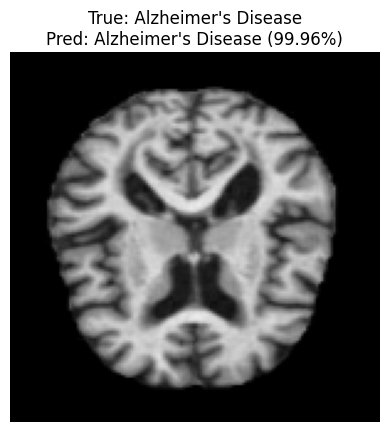

True Label: Alzheimer's Disease
Predicted Label: Alzheimer's Disease
Confidence: 99.96%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


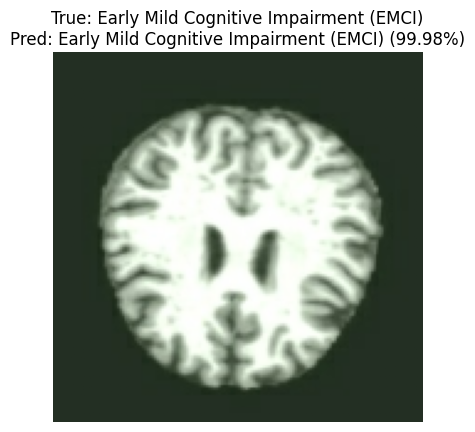

True Label: Early Mild Cognitive Impairment (EMCI)
Predicted Label: Early Mild Cognitive Impairment (EMCI)
Confidence: 99.98%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


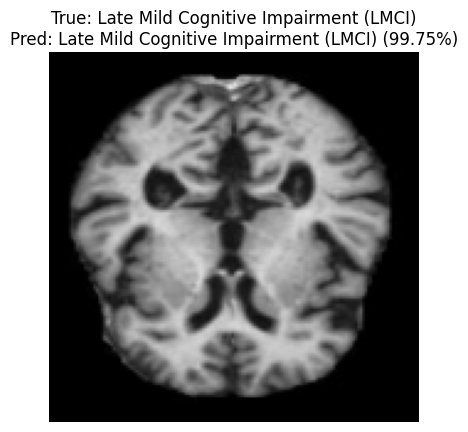

True Label: Late Mild Cognitive Impairment (LMCI)
Predicted Label: Late Mild Cognitive Impairment (LMCI)
Confidence: 99.75%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


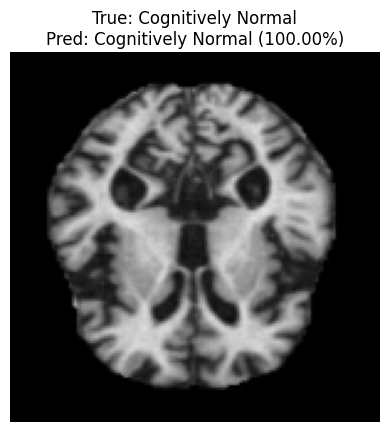

True Label: Cognitively Normal
Predicted Label: Cognitively Normal
Confidence: 100.00%


In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Define the class labels based on your provided information
class_labels = ["Alzheimer's Disease", "Cognitively Normal", 
                "Early Mild Cognitive Impairment (EMCI)", 
                "Late Mild Cognitive Impairment (LMCI)"]


# Assuming val_data is already defined and contains reshaped and normalized images
# You can use the 'take' function to select a batch of images from val_data
for idx, (img_batch, label_batch) in enumerate(val_data.take(1)):  # Take one batch (adjust as needed)
    for i in range(4):  # Process the first 4 images from the batch
        # Extract the image and true label (assuming one-hot encoded labels)
        img = img_batch[i]
        true_class = label_batch[i].numpy().argmax()  # Get the index of the true class
        
        # Predict the image class probabilities
        predictions = model.predict(np.expand_dims(img, axis=0))  # Add batch dimension
        
        # Get the predicted class and confidence
        predicted_class = np.argmax(predictions[0])
        confidence = np.max(predictions[0])

        # Display the image with true and predicted labels
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        plt.title(f"True: {class_labels[true_class]}\nPred: {class_labels[predicted_class]} ({confidence*100:.2f}%)")
        plt.show()

        # Print the true and predicted labels along with confidence
        print(f"True Label: {class_labels[true_class]}")
        print(f"Predicted Label: {class_labels[predicted_class]}")
        print(f"Confidence: {confidence * 100:.2f}%")